# PHÂN TÍCH VÀ DỰ ĐOÁN UNG THƯ VÚ BẰNG KNN

Notebook này trình bày quy trình xây dựng mô hình **K-Nearest Neighbors (KNN)** trên bộ dữ liệu Breast Cancer Wisconsin.

Quy trình gồm:

1. EDA – Khám phá dữ liệu
2. Chia dữ liệu thành Train / Validation / Test
3. Chuẩn hóa dữ liệu bằng StandardScaler
4. Xây dựng mô hình KNN
5. Tìm giá trị K bằng tập Validation
6. Đánh giá mô hình trên tập Test
7. Classification Report
8. Confusion Matrix

## Bước 1: EDA – Khám phá dữ liệu

Trước tiên, đọc dữ liệu và kiểm tra kích thước, kiểu dữ liệu, giá trị thiếu và phân bố của biến mục tiêu `diagnosis`.

- `B`: Benign – khối u lành tính
- `M`: Malignant – khối u ác tính

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
# Đặt file CSV cùng thư mục với notebook hoặc sửa đường dẫn bên dưới
df = pd.read_csv("D:\\KNN_Demo\\breast cancer.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
print("Kích thước dữ liệu:", df.shape)

print("\nThông tin dữ liệu:")
df.info()

print("\nSố lượng giá trị thiếu:")
print(df.isnull().sum())

Kích thước dữ liệu: (569, 33)

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 n

In [6]:
df.isnull().sum().sum()

np.int64(569)

### Trực quan hóa phân bố biến mục tiêu

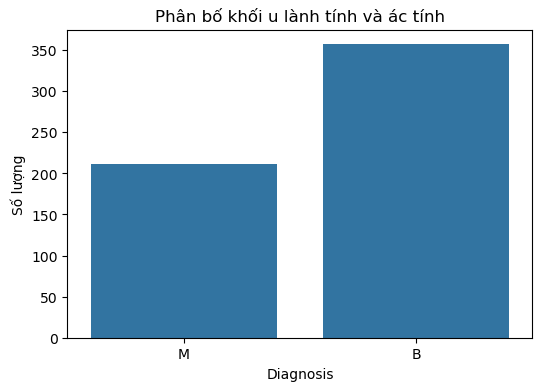

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x="diagnosis", data=df)
plt.title("Phân bố khối u lành tính và ác tính")
plt.xlabel("Diagnosis")
plt.ylabel("Số lượng")
plt.show()

### Kiểm tra tương quan giữa một số đặc trưng

Các biến có hậu tố `_mean` được chọn để quan sát mối quan hệ giữa các đặc trưng.

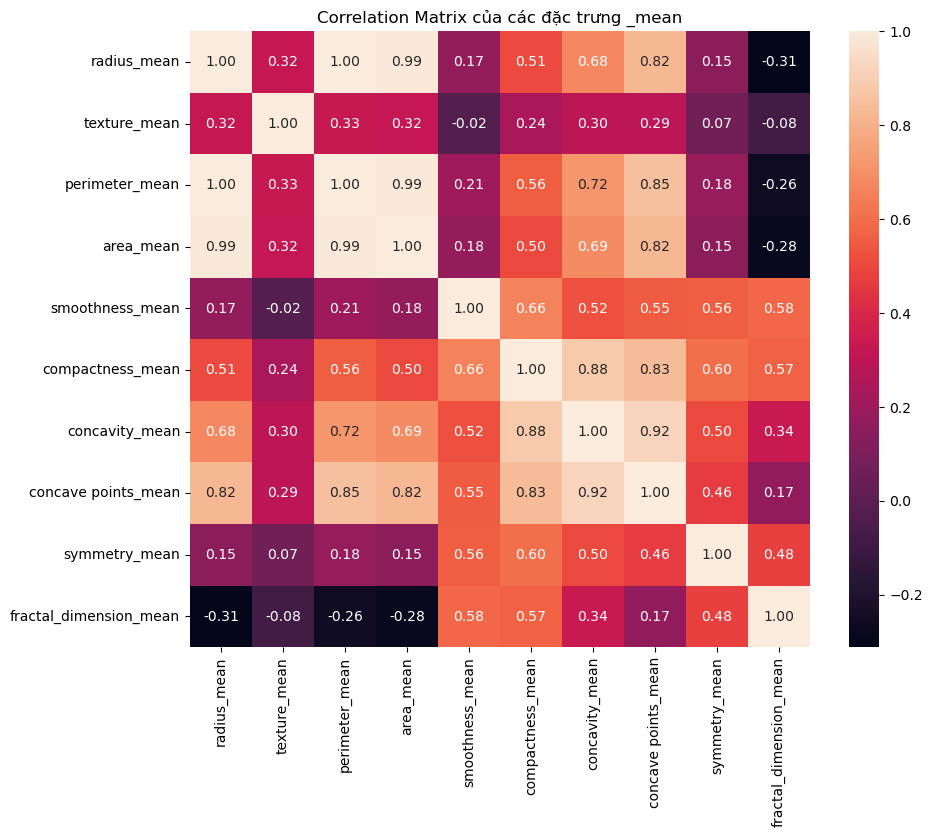

In [4]:
cols_mean = [col for col in df.columns if "_mean" in col]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_mean].corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix của các đặc trưng _mean")
plt.show()

-> Qua EDA, ta kiểm tra được cấu trúc dữ liệu, giá trị thiếu và sự phân bố của hai lớp. Các đặc trưng số có thể được sử dụng làm đầu vào cho KNN. Vì KNN dựa trên khoảng cách giữa các điểm dữ liệu nên bước chuẩn hóa ở phía sau là cần thiết.

## Bước 2: Chia dữ liệu thành Train / Validation / Test

Ở bước này nhóm chia dữ liệu thành 3 tập:

- **Train: 70%** – dùng để huấn luyện mô hình.
- **Validation: 15%** – dùng để thử các giá trị K và chọn K phù hợp.
- **Test: 15%** – dùng ở cuối để đánh giá mô hình.

In [7]:
from sklearn.model_selection import train_test_split

# Xóa các cột không cần thiết
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Chuyển nhãn B/M thành 0/1
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

# Tách đặc trưng và nhãn
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Chia 70% Train và 30% tạm thời
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Chia 30% còn lại thành 15% Validation và 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (398, 30)
Validation: (85, 30)
Test: (86, 30)


=> Dữ liệu được chia thành 3 tập với tỷ lệ khoảng **70% Train – 15% Validation – 15% Test**. Tập Validation sẽ giúp chọn K mà không làm ảnh hưởng đến tập Test.

## Bước 3: Chuẩn hóa dữ liệu bằng StandardScaler

KNN tính khoảng cách giữa các điểm dữ liệu. Nếu các đặc trưng có thang đo khác nhau, đặc trưng có giá trị lớn có thể ảnh hưởng quá mạnh đến khoảng cách.

**Nguyên tắc:** chỉ `fit` trên Train, Validation và Test chỉ dùng `transform`.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hóa dữ liệu Train, Validation và Test.")

Đã chuẩn hóa dữ liệu Train, Validation và Test.


=> Các đặc trưng đã được đưa về thang đo tương đồng. Điều này giúp khoảng cách giữa các điểm dữ liệu được tính hợp lý hơn, từ đó KNN có thể phân loại tốt hơn.

## Bước 4: Xây dựng mô hình KNN

KNN phân loại một mẫu mới dựa trên các điểm dữ liệu gần nó nhất. Tham số quan trọng nhất là **K – số lượng hàng xóm được xem xét**.

Ta sẽ thử nhiều giá trị K thay vì chọn K một cách tùy ý.

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Ví dụ khởi tạo KNN với K = 5
knn_demo = KNeighborsClassifier(n_neighbors=5)
knn_demo.fit(X_train_scaled, y_train)
                
print("Đã huấn luyện mô hình KNN với K = 5.")

Đã huấn luyện mô hình KNN với K = 5.


## Bước 5: Tìm K bằng tập Validation

Ta thử K từ 1 đến 20. Với mỗi K, mô hình được huấn luyện trên Train và đánh giá trên Validation.

Giá trị K có **Validation Accuracy cao nhất** sẽ được chọn.

In [10]:
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
validation_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_val_pred = knn.predict(X_val_scaled)
    accuracy = accuracy_score(y_val, y_val_pred)
    validation_accuracies.append(accuracy)

# Tìm K có Validation Accuracy cao nhất
best_k = k_values[np.argmax(validation_accuracies)]
best_val_accuracy = max(validation_accuracies)

print(f"K được chọn: {best_k}")
print(f"Validation Accuracy: {best_val_accuracy:.4f}")

K được chọn: 3
Validation Accuracy: 0.9647


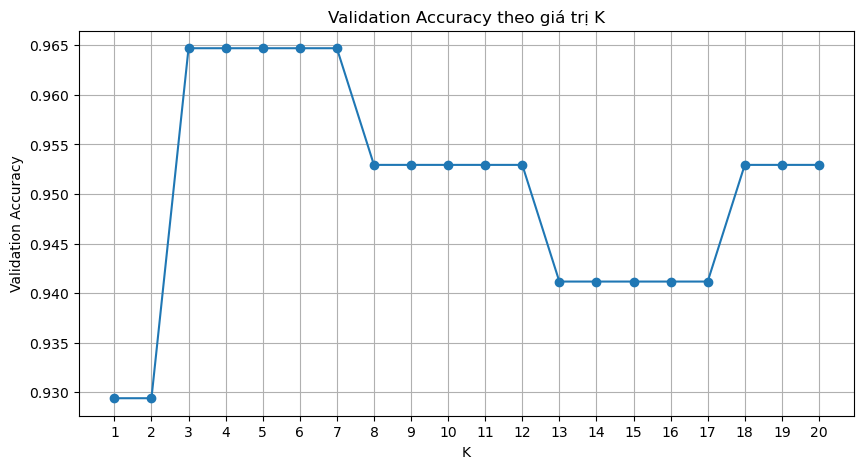

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, validation_accuracies, marker="o")
plt.xlabel("K")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy theo giá trị K")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

=> Giá trị `best_k` là K cho Validation Accuracy cao nhất trong khoảng K = 1 đến 20.

Nếu có nhiều K cho Accuracy bằng nhau hoặc gần bằng nhau, có thể chọn một K phù hợp trong số đó và ghi rõ lý do lựa chọn.

## Bước 6: Đánh giá mô hình trên tập Test

Sau khi đã chọn K bằng Validation, ta dùng K đó để xây dựng mô hình và dự đoán trên **Test set**.

Test set chưa được sử dụng để chọn K nên kết quả Test Accuracy phản ánh khách quan hơn khả năng của mô hình trên dữ liệu chưa được dùng trong quá trình lựa chọn K.

In [13]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
                
# Huấn luyện trên tập Train
final_knn.fit(X_train_scaled, y_train)
                
# Dự đoán trên tập Test
y_test_pred = final_knn.predict(X_test_scaled)
                
# Accuracy trên Test
test_accuracy = accuracy_score(y_test, y_test_pred)
                
print(f"K được chọn: {best_k}")
print(f"Test Accuracy: {test_accuracy:.3f}")

K được chọn: 3
Test Accuracy: 0.953


=> Test Accuracy cho biết tỷ lệ mẫu trong tập Test được KNN phân loại đúng sau khi K đã được lựa chọn bằng Validation. Đây là chỉ số quan trọng để đánh giá kết quả cuối cùng của mô hình.

## Bước 7: Classification Report

Classification Report cung cấp các chỉ số:

- **Precision:** trong các mẫu được dự đoán thuộc một lớp, có bao nhiêu mẫu thực sự thuộc lớp đó.
- **Recall:** trong các mẫu thực sự thuộc một lớp, mô hình phát hiện đúng bao nhiêu mẫu.
- **F1-score:** kết hợp Precision và Recall.
- **Support:** số lượng mẫu thực tế của từng lớp.

In [14]:
from sklearn.metrics import classification_report

print("=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Lành tính (B)", "Ác tính (M)"]
))

=== CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

Lành tính (B)       0.93      1.00      0.96        54
  Ác tính (M)       1.00      0.88      0.93        32

     accuracy                           0.95        86
    macro avg       0.97      0.94      0.95        86
 weighted avg       0.96      0.95      0.95        86



=> Classification Report cho biết mô hình không chỉ dự đoán đúng bao nhiêu phần trăm mà còn cho biết khả năng nhận diện từng lớp. Nếu Precision, Recall và F1-score đều cao thì mô hình có khả năng phân loại tương đối tốt, tuy nhiên vẫn cần xem Confusion Matrix để biết cụ thể mô hình nhầm ở đâu.

## Bước 8: Confusion Matrix

Confusion Matrix cho biết số lượng mẫu được dự đoán đúng và dự đoán sai ở từng lớp.

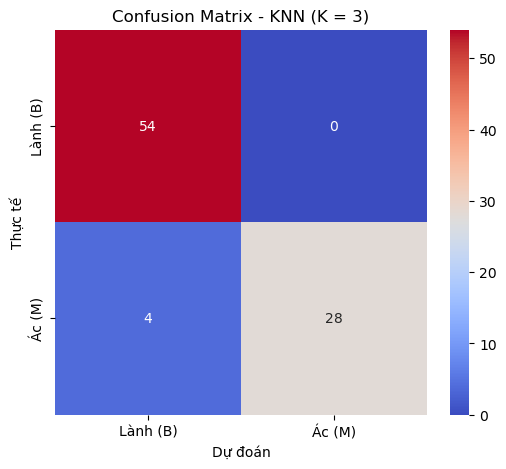

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap='coolwarm',
    xticklabels=["Lành (B)", "Ác (M)"],
    yticklabels=["Lành (B)", "Ác (M)"]
)
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.title(f"Confusion Matrix - KNN (K = {best_k})")
plt.show()

=> Mô hình dự đoán đúng 54 ca lành tính và 28 ca ác tính. Có 4 ca ác tính bị dự đoán nhầm thành lành tính và không có trường hợp lành tính nào bị dự đoán nhầm thành ác tính.

- Ô **Lành → Lành**: dự đoán đúng mẫu lành tính.
- Ô **Ác → Ác**: dự đoán đúng mẫu ác tính.
- Ô **Lành → Ác**: mô hình dự đoán nhầm lành tính thành ác tính.
- Ô **Ác → Lành**: mô hình dự đoán nhầm ác tính thành lành tính.

### Kết luận cuối cùng

- Dữ liệu cho thấy mô hình KNN có khả năng phân biệt khá tốt giữa khối u lành tính và ác tính.
- Sau khi chuẩn hóa dữ liệu và lựa chọn giá trị K phù hợp, mô hình đạt độ chính xác cao (~95,3%) trên tập kiểm tra.
- Phần lớn các mẫu được dự đoán đúng, tuy nhiên vẫn còn một số trường hợp bị phân loại sai.
- Do đó, KNN có thể được sử dụng như một công cụ hỗ trợ phân tích, nhưng không thay thế chẩn đoán y khoa thực tế.